In [32]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         # print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
import numpy as np
import pandas as pd
import os

In [4]:
import cv2
from PIL import Image

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report , confusion_matrix

In [6]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input,Conv2D,MaxPooling2D,UpSampling2D,
                                    Concatenate,Dropout,BatchNormalization)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import(ModelCheckpoint,EarlyStopping,ReduceLROnPlateau)

2026-05-10 11:02:52.742373: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778410973.132943      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778410973.242374      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778410974.203150      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778410974.203190      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778410974.203193      57 computation_placer.cc:177] computation placer alr

In [7]:
from tensorflow.keras import backend as K

In [8]:
import warnings
warnings.filterwarnings('ignore')

In [9]:
from glob import glob

base_path = "/kaggle/input/datasets/briscdataset/brisc2025/brisc2025/segmentation_task/train"

image_dir = os.path.join(base_path, "images")
mask_dir = os.path.join(base_path, "masks")

image_paths = sorted(glob(os.path.join(image_dir, "*.*")))
mask_paths = sorted(glob(os.path.join(mask_dir, "*.*")))

df = pd.DataFrame({
    "image_path": image_paths,
    "mask_path": mask_paths
})

In [10]:
df.head()

,image_path,mask_path
0,/kaggle/input/datasets/briscdataset/brisc2025/...,/kaggle/input/datasets/briscdataset/brisc2025/...
1,/kaggle/input/datasets/briscdataset/brisc2025/...,/kaggle/input/datasets/briscdataset/brisc2025/...
2,/kaggle/input/datasets/briscdataset/brisc2025/...,/kaggle/input/datasets/briscdataset/brisc2025/...
3,/kaggle/input/datasets/briscdataset/brisc2025/...,/kaggle/input/datasets/briscdataset/brisc2025/...
4,/kaggle/input/datasets/briscdataset/brisc2025/...,/kaggle/input/datasets/briscdataset/brisc2025/...


In [11]:
df.tail()

,image_path,mask_path
3928,/kaggle/input/datasets/briscdataset/brisc2025/...,/kaggle/input/datasets/briscdataset/brisc2025/...
3929,/kaggle/input/datasets/briscdataset/brisc2025/...,/kaggle/input/datasets/briscdataset/brisc2025/...
3930,/kaggle/input/datasets/briscdataset/brisc2025/...,/kaggle/input/datasets/briscdataset/brisc2025/...
3931,/kaggle/input/datasets/briscdataset/brisc2025/...,/kaggle/input/datasets/briscdataset/brisc2025/...
3932,/kaggle/input/datasets/briscdataset/brisc2025/...,/kaggle/input/datasets/briscdataset/brisc2025/...


In [12]:
df.shape

(3933, 2)

In [13]:
df.columns

Index(['image_path', 'mask_path'], dtype='object')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3933 entries, 0 to 3932
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  3933 non-null   object
 1   mask_path   3933 non-null   object
dtypes: object(2)
memory usage: 61.6+ KB


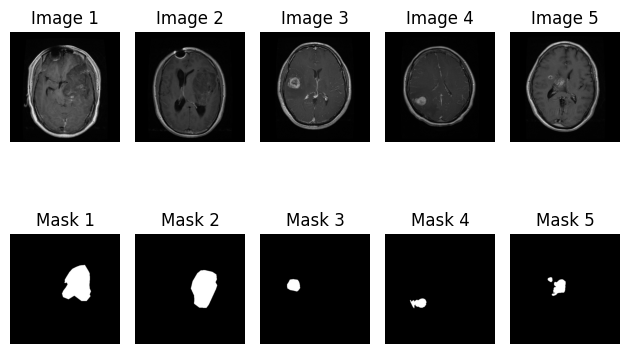

In [15]:
import matplotlib.pyplot as plt
import cv2

num_samples=5

for i in range(num_samples):
    img_path = df.iloc[i]["image_path"]
    mask_path = df.iloc[i]["mask_path"]

    img = cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)
    mask=cv2.imread(mask_path,cv2.IMREAD_GRAYSCALE)

    # First riw -> Images
    plt.subplot(2, num_samples, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"Image {i+1}")
    plt.axis("off")


    plt.subplot(2, num_samples, num_samples + i + 1)
    plt.imshow(mask, cmap="gray")
    plt.title(f"Mask {i+1}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [16]:
#  Performing some basic operations - eg normalization 

IMG_SIZE=256

def load_image(path):
    img = cv2.imread(path,cv2.IMREAD_GRAYSCALE)
    img=cv2.resize(img,(IMG_SIZE,IMG_SIZE))
    img=img.astype("float32")/255.0
    img = np.expand_dims(img,axis=-1)
    return img
    
def load_mask(path):
    mask = cv2.imread(path,cv2.IMREAD_GRAYSCALE)
    mask=cv2.resize(mask,(IMG_SIZE,IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    mask=mask.astype("float32")/255.0
    mask=(mask>0.5).astype("float32")
    mask = np.expand_dims(mask,axis=-1)
    return mask

In [17]:
def data_generator(df):
    while True:
        for i in range(len(df)):
            img=load_image(df.iloc[i]["image_path"])
            mask=load_mask(df.iloc[i]["mask_path"])
            yield np.expand_dims(img,0),np.expand_dims(mask,0)
            
        

In [18]:
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / \
           (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def iou_metric(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection

    return (intersection + smooth) / (union + smooth)

In [19]:
from tensorflow.keras import layers, Model

def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same", kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(filters, 3, padding="same", kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    return x

def unet():
    inputs = layers.Input((IMG_SIZE, IMG_SIZE, 1))  # ✅ grayscale MRI

    # Encoder
    c1 = conv_block(inputs, 64);  p1 = layers.MaxPool2D((2,2))(c1)
    c2 = conv_block(p1, 128);     p2 = layers.MaxPool2D((2,2))(c2)
    c3 = conv_block(p2, 256);     p3 = layers.MaxPool2D((2,2))(c3)
    c4 = conv_block(p3, 512);     p4 = layers.MaxPool2D((2,2))(c4)

    # Bottleneck
    bn = conv_block(p4, 1024)

    # Decoder
    u1 = layers.Conv2DTranspose(512, 2, strides=2, padding="same")(bn)
    u1 = layers.Concatenate()([u1, c4])
    c5 = conv_block(u1, 512)

    u2 = layers.Conv2DTranspose(256, 2, strides=2, padding="same")(c5)
    u2 = layers.Concatenate()([u2, c3])
    c6 = conv_block(u2, 256)

    u3 = layers.Conv2DTranspose(128, 2, strides=2, padding="same")(c6)
    u3 = layers.Concatenate()([u3, c2])
    c7 = conv_block(u3, 128)

    u4 = layers.Conv2DTranspose(64, 2, strides=2, padding="same")(c7)
    u4 = layers.Concatenate()([u4, c1])
    c8 = conv_block(u4, 64)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(c8)

    model = Model(inputs, outputs, name="U-Net_MRI")
    return model

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
train_df, val_df = train_test_split(df, test_size=0.2, shuffle=True, random_state=42)

train_gen = data_generator(train_df)
val_gen = data_generator(val_df)

steps_train = len(train_df)
steps_val = len(val_df)

In [22]:
from tensorflow.keras import layers
from tensorflow.keras.models import Model

In [23]:
model = unet()
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", dice_coef, iou_metric]
)

model.summary()

I0000 00:00:1778411011.234764      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778411011.240886      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "U-Net_MRI"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_4[0][0]  

 Total params: 31,054,145 (118.46 MB)

 Trainable params: 31,042,369 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

In [24]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    steps_per_epoch=steps_train,
    validation_steps=steps_val,
    epochs=10
)

Epoch 1/10


I0000 00:00:1778411024.233157     132 service.cc:152] XLA service 0x7ca4a40022d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778411024.233194     132 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778411024.233197     132 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778411026.397625     132 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-10 11:03:50.015087: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 11:03:50.210312: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-10 11:03:50.693357: E external/local_xl

   1/3146 ━━━━━━━━━━━━━━━━━━━━ 32:53:57 38s/step - accuracy: 0.4562 - dice_coef: 0.0127 - iou_metric: 0.0064 - loss: 0.9331

I0000 00:00:1778411051.063491     132 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3146/3146 ━━━━━━━━━━━━━━━━━━━━ 362s 103ms/step - accuracy: 0.9790 - dice_coef: 0.1743 - iou_metric: 0.1101 - loss: 0.0812 - val_accuracy: 0.9800 - val_dice_coef: 0.3176 - val_iou_metric: 0.2290 - val_loss: 0.0714
Epoch 2/10
3146/3146 ━━━━━━━━━━━━━━━━━━━━ 322s 102ms/step - accuracy: 0.9892 - dice_coef: 0.4398 - iou_metric: 0.3141 - loss: 0.0352 - val_accuracy: 0.9688 - val_dice_coef: 0.3753 - val_iou_metric: 0.2758 - val_loss: 0.1176
Epoch 3/10
3146/3146 ━━━━━━━━━━━━━━━━━━━━ 322s 102ms/step - accuracy: 0.9907 - dice_coef: 0.5183 - iou_metric: 0.3871 - loss: 0.0284 - val_accuracy: 0.9594 - val_dice_coef: 0.3994 - val_iou_metric: 0.2913 - val_loss: 0.2002
Epoch 4/10
3146/3146 ━━━━━━━━━━━━━━━━━━━━ 322s 102ms/step - accuracy: 0.9916 - dice_coef: 0.5628 - iou_metric: 0.4315 - loss: 0.0250 - val_accuracy: 0.9759 - val_dice_coef: 0.4430 - val_iou_metric: 0.3409 - val_loss: 0.1125
Epoch 5/10
3146/3146 ━━━━━━━━━━━━━━━━━━━━ 322s 102ms/step - accuracy: 0.9924 - dice_coef: 0.5980 - iou_metric: 0.46

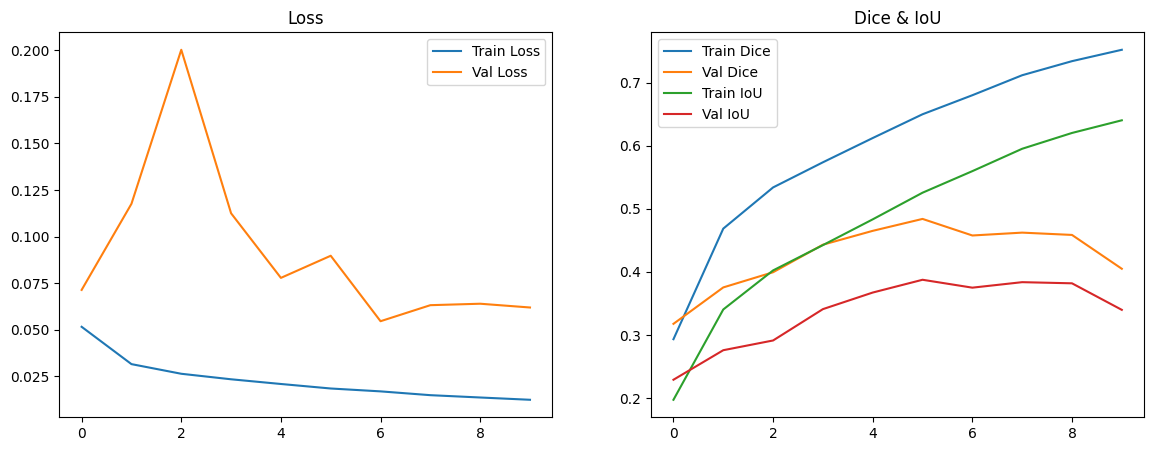

In [25]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["dice_coef"], label="Train Dice")
plt.plot(history.history["val_dice_coef"], label="Val Dice")
plt.plot(history.history["iou_metric"], label="Train IoU")
plt.plot(history.history["val_iou_metric"], label="Val IoU")
plt.title("Dice & IoU")
plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


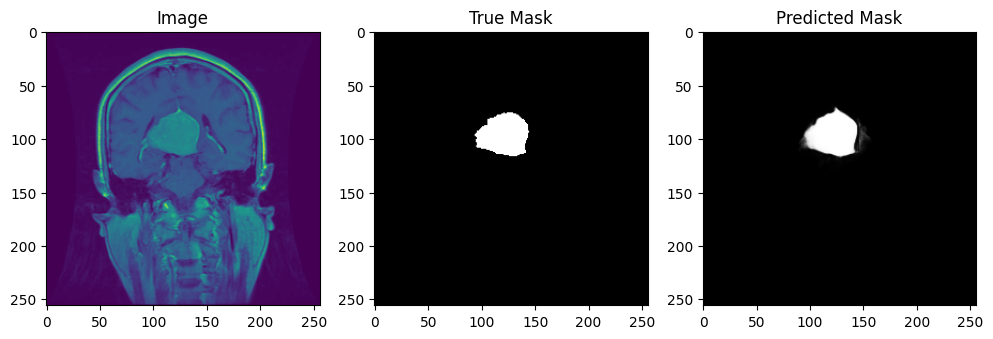

In [33]:
idx = 0
test_img = load_image(val_df.iloc[idx]["image_path"])
test_mask = load_mask(val_df.iloc[idx]["mask_path"])

pred = model.predict(np.expand_dims(test_img, 0))[0]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(test_img)
plt.title("Image")

plt.subplot(1,3,2)
plt.imshow(test_mask[:, :, 0], cmap="gray")
plt.title("True Mask")

plt.subplot(1,3,3)
plt.imshow(pred[:, :, 0], cmap="gray")
plt.title("Predicted Mask")

plt.show()